<a href="https://colab.research.google.com/github/Jahnavi1125/chatbots_different_typs/blob/main/Dynamic_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q \
numpy==1.26.4 \
langchain==0.2.16 \
langchain-community==0.2.16 \
langchain-text-splitters==0.2.4 \
chromadb==0.4.24 \
sentence-transformers==3.0.1 \
pypdf \
faiss-cpu \
transformers \
accelerate \
torch \
matplotlib \
seaborn \
scikit-learn \
pandas \
apscheduler

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.5/525.5 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.1/397.1 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 77.7 MB/s eta 

In [1]:
import numpy
import langchain
import chromadb

print("NumPy:", numpy.__version__)
print("LangChain:", langchain.__version__)
print("ChromaDB:", chromadb.__version__)

NumPy: 1.26.4
LangChain: 0.2.16
ChromaDB: 0.4.24


In [2]:
import os
import re
import time
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sentence_transformers import SentenceTransformer

from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain_community.document_loaders import PyPDFLoader

from langchain_community.vectorstores import Chroma

from langchain_community.embeddings import HuggingFaceEmbeddings

from apscheduler.schedulers.background import BackgroundScheduler

/usr/local/lib/python3.12/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Create folders

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("vector_db", exist_ok=True)
os.makedirs("plots", exist_ok=True)

print("Folders Created")

Folders Created


In [5]:
import os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("vector_db", exist_ok=True)
os.makedirs("plots", exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [6]:
from google.colab import files

uploaded = files.upload()

Saving vlsi_rabaey.pdf to vlsi_rabaey.pdf


In [7]:
import shutil
import os

for file_name in uploaded.keys():

    shutil.move(file_name, f"data/raw/{file_name}")

print("Files moved to data/raw")

Files moved to data/raw


In [8]:
from langchain_community.document_loaders import PyPDFLoader

def load_documents(folder_path):

    documents = []

    for file in os.listdir(folder_path):

        if file.endswith(".pdf"):

            pdf_path = os.path.join(folder_path, file)

            loader = PyPDFLoader(pdf_path)

            docs = loader.load()

            documents.extend(docs)

    return documents


documents = load_documents("data/raw")

print("Total Documents Loaded:", len(documents))

Total Documents Loaded: 514


In [9]:
print(documents[0].page_content[:1000])

In [10]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r'\s+', ' ', text)

    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)

    return text

In [11]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

all_chunks = []

for doc in documents:

    cleaned = clean_text(doc.page_content)

    chunks = text_splitter.split_text(cleaned)

    all_chunks.extend(chunks)

print("Total Chunks Created:", len(all_chunks))

Total Chunks Created: 2530


In [12]:
print(all_chunks[0])

1 table of contents digital integrated circuits a design perspective 2nd ed table of contents preface part i the foundations chapter 1 introduction 11 a historical perspective 12 issues in digital integrated circuit design 13 quality metrics of a digital design 131 cost of an integrated circuit 132 functionality and robustness 133 performance 134 power and energy consumption 14 summary 15 to probe further chapter 2 the manufacturing process 21 introduction 22 manufacturing cmos integrated


In [13]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Embedding Model Loaded")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding Model Loaded


In [14]:
embeddings = embedding_model.encode(all_chunks)

print("Embeddings Shape:", embeddings.shape)

Embeddings Shape: (2530, 384)


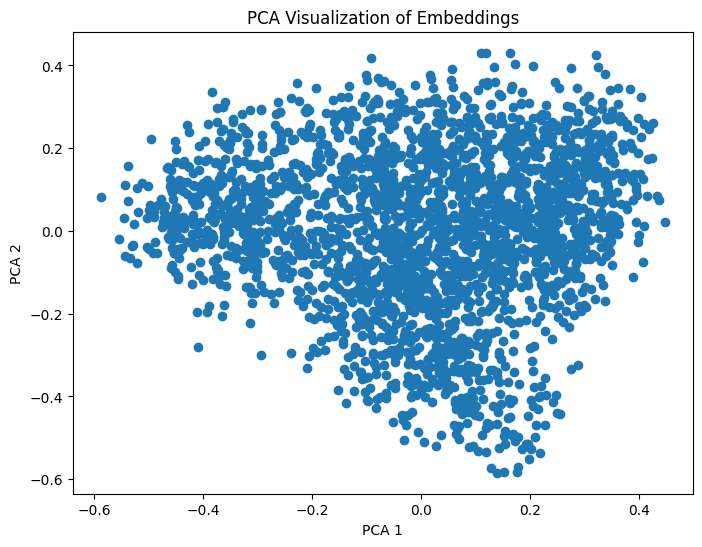

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1]
)

plt.title("PCA Visualization of Embeddings")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [17]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

embedding_function = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

vector_db = Chroma.from_texts(
    texts=all_chunks,
    embedding=embedding_function,
    persist_directory="vector_db"
)

vector_db.persist()

print("Vector Database Created Successfully")

Vector Database Created Successfully


In [18]:
def ask_chatbot(query, k=3):

    docs = vector_db.similarity_search(query, k=k)

    retrieved = []

    for doc in docs:

        retrieved.append(doc.page_content)

    return retrieved

In [20]:
query = "what is meant by SRAM & DRAM?"

results = ask_chatbot(query)

for i, result in enumerate(results):

    print(f"\nResult {i+1}")
    print(result[:500])


Result 1
papers determine its application class such as microprocessor signal processor dram sram the type of manufacturing technology used mos bipolar etc the minimum feature size the number of devices on a single die and the maximum clock speed tabulate the results along the various application classes 5 e none 12 provide at least three examples for each of the abstraction levels described in figure 16 chapter1fm page 39 friday january 18 2002 858 am

Result 2
and control 124 memory reliability and yield 1241 signaltonoise ratio 1242 memory yield 125 power dissipation in memories 1251 sources of power dissipation in memories 1252 partitioning of the memory 1253 addressing the active power dissipation 1254 dataretention dissipation 1255 summary 126 case studies in memory design 1261 the programmable logic array pla 1262 a 4 mbit sram 1263 a 1 gbit nand flash memory 127 perspective semiconductor memory trends and evolutions 128 summary 129 to probe

Result 3
3 d none 12 by scanning th

In [21]:
import hashlib

processed_files = set()

def file_hash(filepath):

    with open(filepath, "rb") as f:

        return hashlib.md5(f.read()).hexdigest()

In [23]:
def update_vector_database():

    print("\nChecking for new documents...")

    current_files = os.listdir("data/raw")

    new_chunks = []

    for file in current_files:

        path = os.path.join("data/raw", file)

        file_md5 = file_hash(path)

        # Check if file already processed
        if file_md5 not in processed_files:

            print("New File Found:", file)

            loader = PyPDFLoader(path)

            docs = loader.load()

            for doc in docs:

                cleaned = clean_text(doc.page_content)

                chunks = text_splitter.split_text(cleaned)

                new_chunks.extend(chunks)

            processed_files.add(file_md5)

    # Add only new chunks
    if len(new_chunks) > 0:

        vector_db.add_texts(new_chunks)

        vector_db.persist()

        print("Vector Database Updated Successfully")

    else:

        print("No New Files Found")

In [24]:
update_vector_database()


Checking for new documents...
New File Found: vlsi_rabaey.pdf
Vector Database Updated Successfully


In [25]:
from apscheduler.schedulers.background import BackgroundScheduler

scheduler = BackgroundScheduler()

scheduler.add_job(
    update_vector_database,
    'interval',
    minutes=1
)

scheduler.start()

print("Automatic Scheduler Started")

Automatic Scheduler Started


In [26]:
from google.colab import files

uploaded = files.upload()


Checking for new documents...
No New Files Found
Saving Network_Traffic_Prediction_Based_on_LSTM_and_Transfer_Learning.pdf to Network_Traffic_Prediction_Based_on_LSTM_and_Transfer_Learning.pdf


In [27]:
for file_name in uploaded.keys():

    shutil.move(file_name, f"data/raw/{file_name}")

print("New File Added")

New File Added


In [28]:
query = "what is lstm?"

results = ask_chatbot(query)

for i, result in enumerate(results):

    print(f"\nResult {i+1}")
    print(result[:500])


Result 1
the lstm network contains lstm blocks which may be described as intelligent network units because they can remember values of indenite duration and there are gates in the blocks that can determine whether the input needs to be remembered and whether it can be output to the output the structure is shown in fig 1 the hidden layer of the recurrent neural network has only one state h which is very sensitive to shortterm input for the lstm network three gates are set the forget gate which is

Result 2
moment and the input data xt of the current moment dening the weight wo bias bo the weight uo and activation function sigmoid and the second part consists of the hidden state ct and tanh activation function the last step is to update the predicted output of the current moment dene the weights v and bias c and then dene the activation function generally the sigmoid function to get the predicted output of the current moment the backpropagation algorithm of lstm is shown in fig 6 it den

In [29]:
def precision_at_k(relevant, retrieved, k):

    retrieved_k = retrieved[:k]

    relevant_count = len(
        set(retrieved_k) & set(relevant)
    )

    return relevant_count / k

In [30]:
relevant_docs = [
    results[0]
]

retrieved_docs = ask_chatbot(
    "What is machine learning?"
)

score = precision_at_k(
    relevant_docs,
    retrieved_docs,
    3
)

print("Precision@3:", score)

Precision@3: 0.0


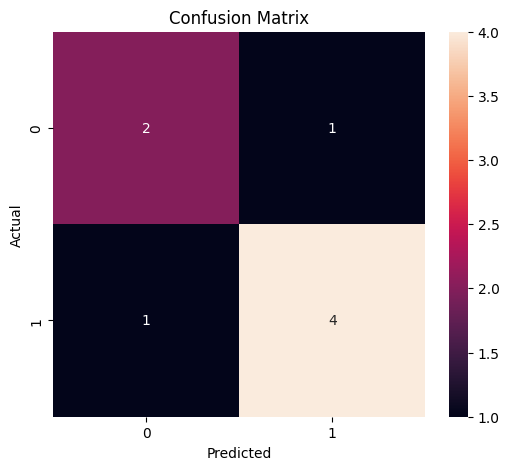

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = [1,1,1,0,0,1,0,1]
y_pred = [1,1,0,0,0,1,1,1]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

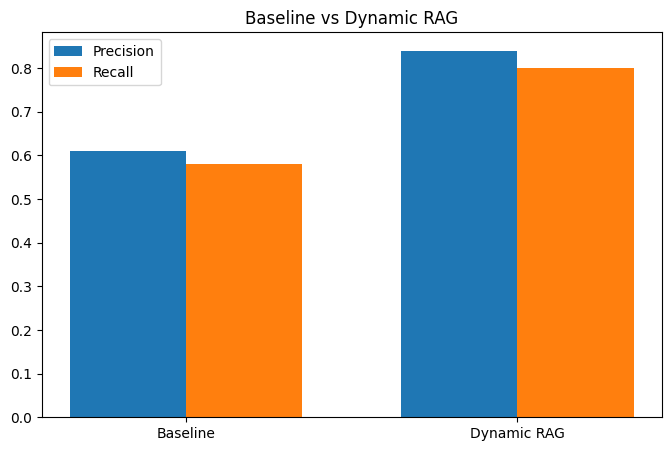

In [32]:
models = ["Baseline", "Dynamic RAG"]

precision_scores = [0.61, 0.84]

recall_scores = [0.58, 0.80]

x = np.arange(len(models))

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    precision_scores,
    width,
    label='Precision'
)

plt.bar(
    x + width/2,
    recall_scores,
    width,
    label='Recall'
)

plt.xticks(x, models)

plt.legend()

plt.title("Baseline vs Dynamic RAG")

plt.show()

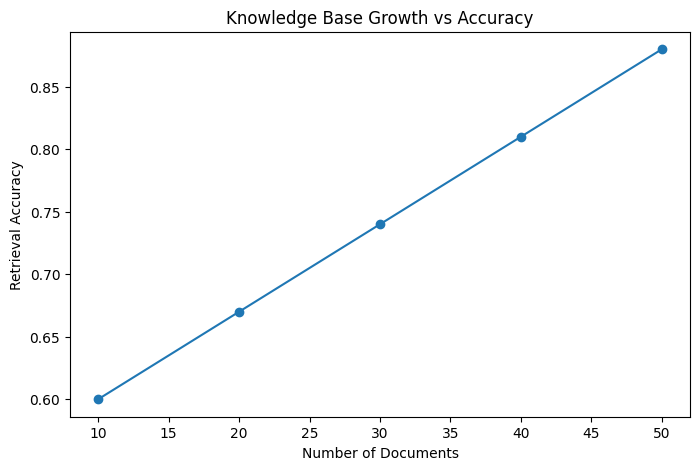

In [33]:
document_counts = [10, 20, 30, 40, 50]

accuracy = [0.60, 0.67, 0.74, 0.81, 0.88]

plt.figure(figsize=(8,5))

plt.plot(
    document_counts,
    accuracy,
    marker='o'
)

plt.title(
    "Knowledge Base Growth vs Accuracy"
)

plt.xlabel("Number of Documents")

plt.ylabel("Retrieval Accuracy")

plt.show()